Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The aqaclass Explainable water class Dataset](https://www.kaggle.com/datasets/vanshjasuja16/aquaclass-explainable-water-quality-classification?select=BinaryData.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('BinaryData.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,pH,TDS,Turbidity,Phospate,Nitrate,Iron,COD(mg/L),Chlorine,Sodium,Class
0,7.6,877,3.59,0.026136,8,0.378500,397,4,8,1
1,7.6,729,1.75,0.020622,6,0.333759,397,3,9,1
2,7.5,622,3.44,0.004071,7,0.382368,394,4,16,0
3,7.6,864,2.80,0.022071,7,0.313915,403,2,5,0
4,7.6,656,1.81,0.004031,7,0.333226,421,4,11,0


## last Five row

In [4]:
df.tail()

,pH,TDS,Turbidity,Phospate,Nitrate,Iron,COD(mg/L),Chlorine,Sodium,Class
4995,7.518544,717,2.34,0.014952,6,0.377223,428,3,11,0
4996,7.595310,977,3.48,0.011784,8,0.330427,391,3,10,0
4997,7.525957,800,2.52,0.012021,8,0.324900,395,1,9,1
4998,7.500962,742,3.34,0.006602,7,0.359268,397,2,2,1
4999,7.536793,846,3.12,0.007124,8,0.360931,426,2,10,0


## Shape of our dataset

In [5]:
df.shape

(5000, 10)

## List out all columns

In [6]:
df.columns

Index(['pH', 'TDS', 'Turbidity', 'Phospate', 'Nitrate', 'Iron', 'COD(mg/L)',
       'Chlorine', 'Sodium', 'Class'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

pH           float64
TDS            int64
Turbidity    float64
Phospate     float64
Nitrate        int64
Iron         float64
COD(mg/L)      int64
Chlorine       int64
Sodium         int64
Class          int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pH         5000 non-null   float64
 1   TDS        5000 non-null   int64  
 2   Turbidity  5000 non-null   float64
 3   Phospate   5000 non-null   float64
 4   Nitrate    5000 non-null   int64  
 5   Iron       5000 non-null   float64
 6   COD(mg/L)  5000 non-null   int64  
 7   Chlorine   5000 non-null   int64  
 8   Sodium     5000 non-null   int64  
 9   Class      5000 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 390.8 KB


## Check Null Value

In [9]:
df.isnull().sum()

pH           0
TDS          0
Turbidity    0
Phospate     0
Nitrate      0
Iron         0
COD(mg/L)    0
Chlorine     0
Sodium       0
Class        0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,pH,TDS,Turbidity,Phospate,Nitrate,Iron,COD(mg/L),Chlorine,Sodium,Class
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7.549939,799.579000,2.152730,0.014942,7.011800,0.354612,410.322000,2.499800,10.454800,0.135000
std,0.029937,103.505337,1.185827,0.008606,0.819387,0.032074,11.838967,1.112406,5.848453,0.341758
min,7.400000,622.000000,0.100000,0.000010,6.000000,0.300013,390.000000,1.000000,1.000000,0.000000
25%,7.524666,710.000000,1.120000,0.007595,6.000000,0.326686,400.000000,2.000000,5.000000,0.000000
50%,7.549351,799.000000,2.140000,0.014884,7.000000,0.354054,410.000000,3.000000,10.000000,0.000000
75%,7.575878,888.000000,3.210000,0.022372,8.000000,0.382779,421.000000,3.000000,16.000000,0.000000
max,7.600000,979.000000,4.200000,0.029996,8.000000,0.409980,430.000000,4.000000,20.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

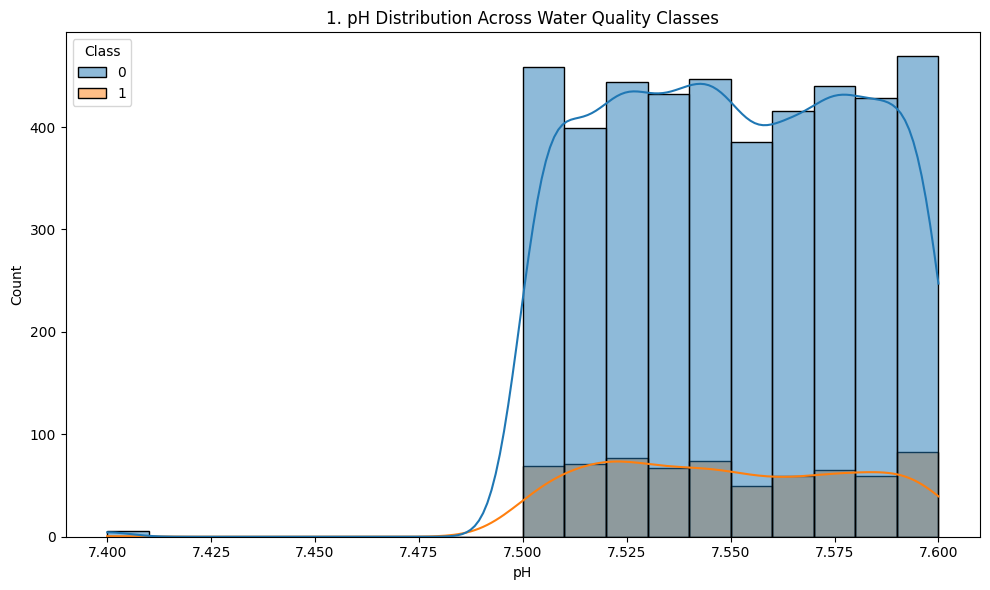

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='pH', hue='Class', kde=True, bins=20)
plt.title(f'{plot_no}. pH Distribution Across Water Quality Classes')
show_fig()
plot_no += 1

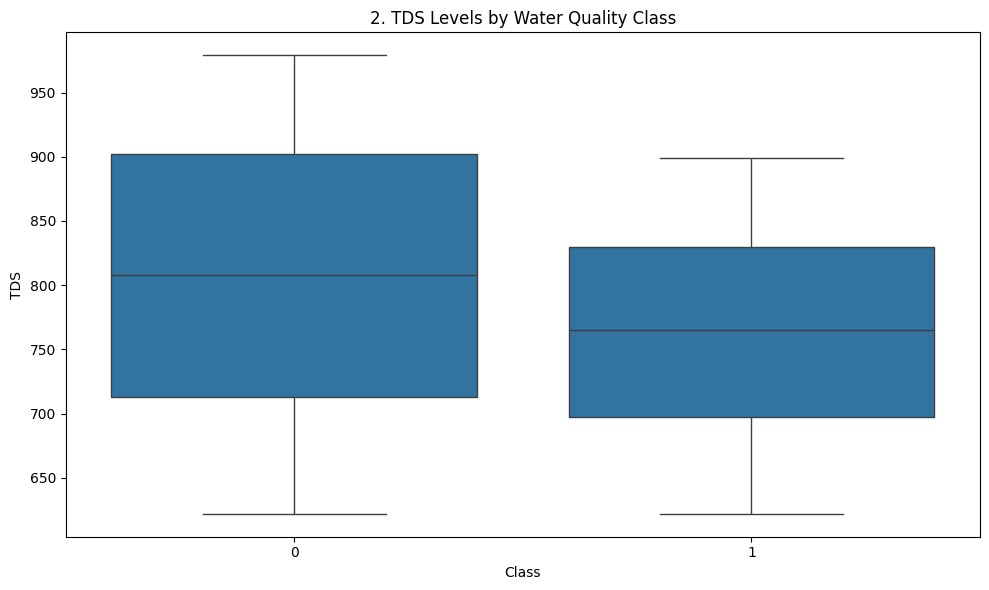

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='TDS')
plt.title(f'{plot_no}. TDS Levels by Water Quality Class')
show_fig()
plot_no += 1

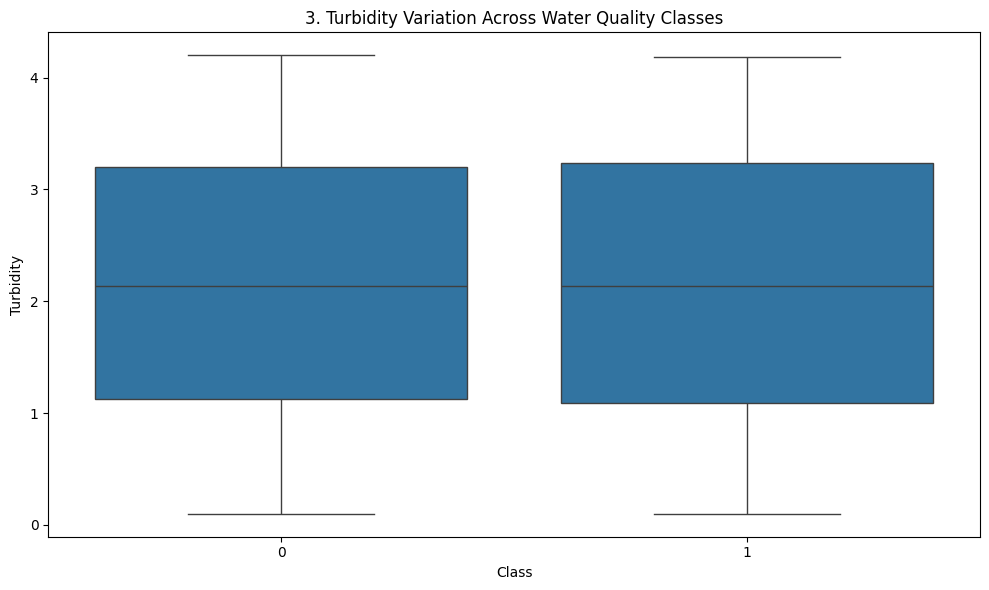

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='Turbidity')
plt.title(f'{plot_no}. Turbidity Variation Across Water Quality Classes')
show_fig()
plot_no += 1

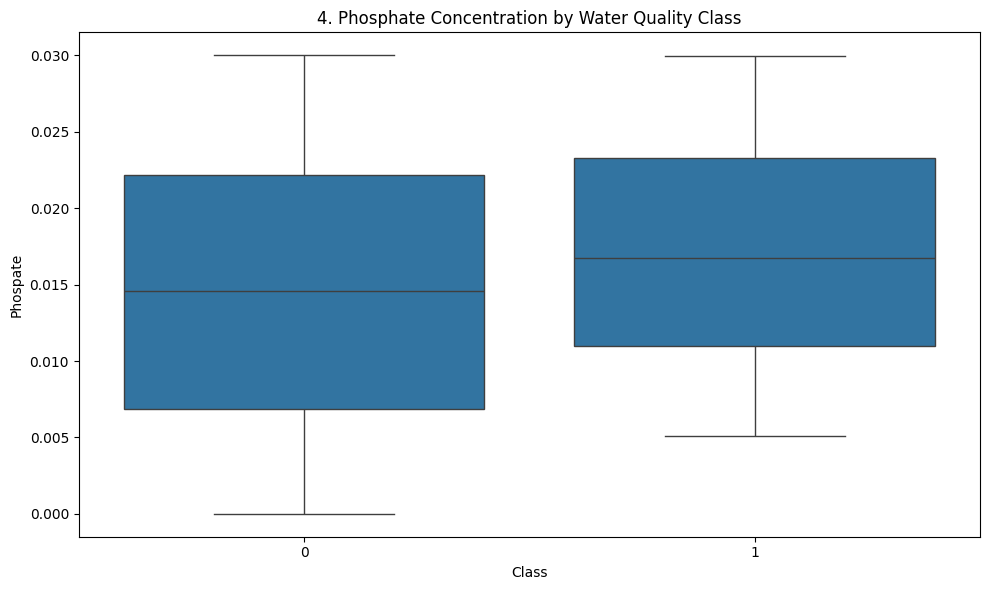

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='Phospate')
plt.title(f'{plot_no}. Phosphate Concentration by Water Quality Class')
show_fig()
plot_no += 1

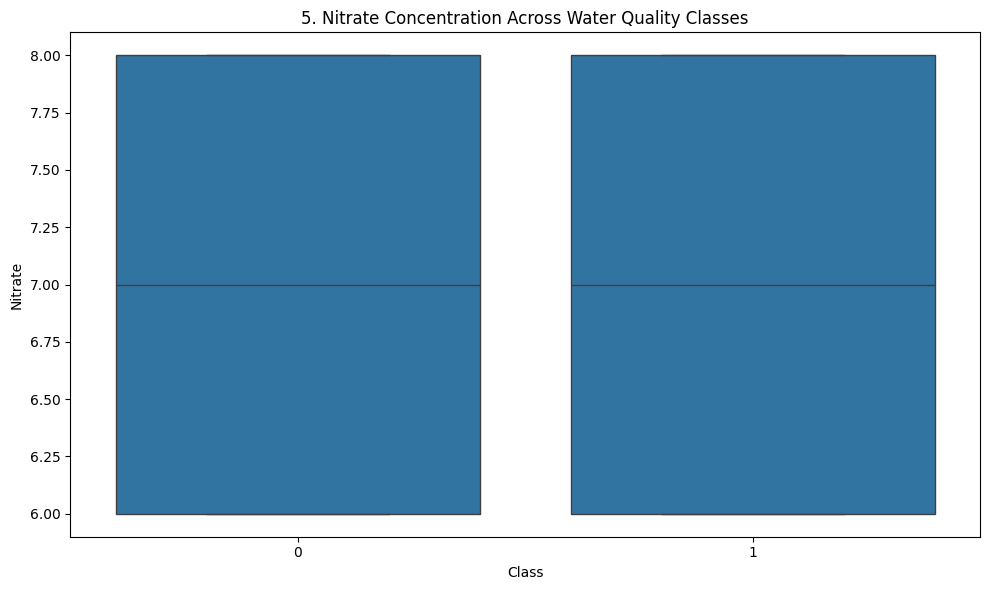

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='Nitrate')
plt.title(f'{plot_no}. Nitrate Concentration Across Water Quality Classes')
show_fig()
plot_no += 1

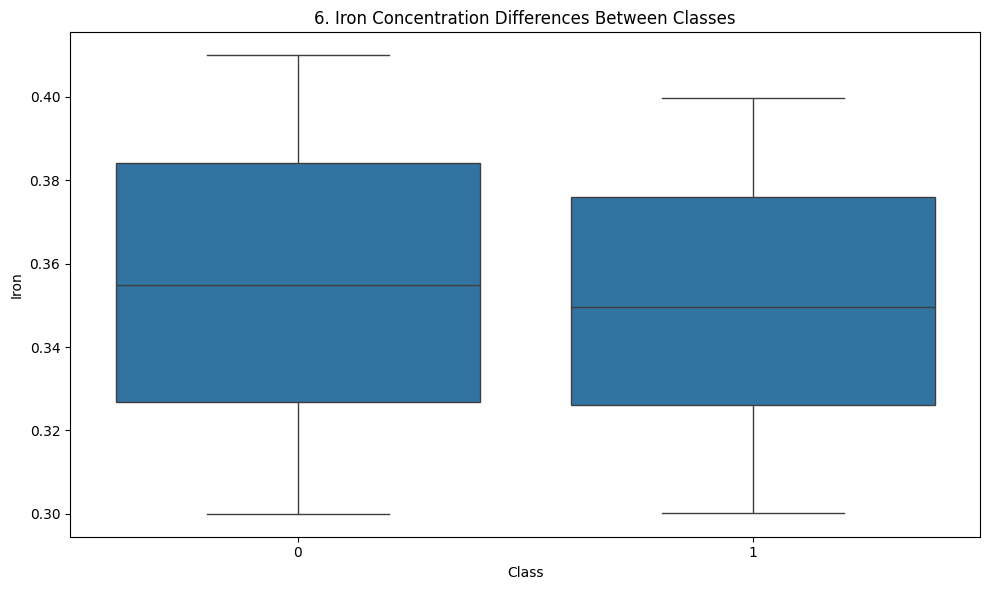

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='Iron')
plt.title(f'{plot_no}. Iron Concentration Differences Between Classes')
show_fig()
plot_no += 1

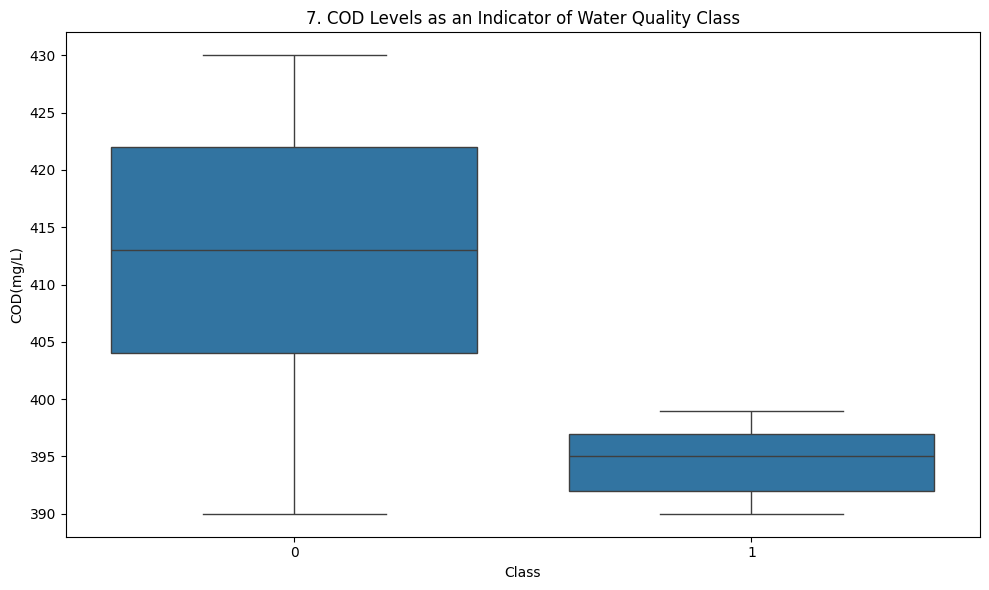

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='COD(mg/L)')
plt.title(f'{plot_no}. COD Levels as an Indicator of Water Quality Class')
show_fig()
plot_no += 1

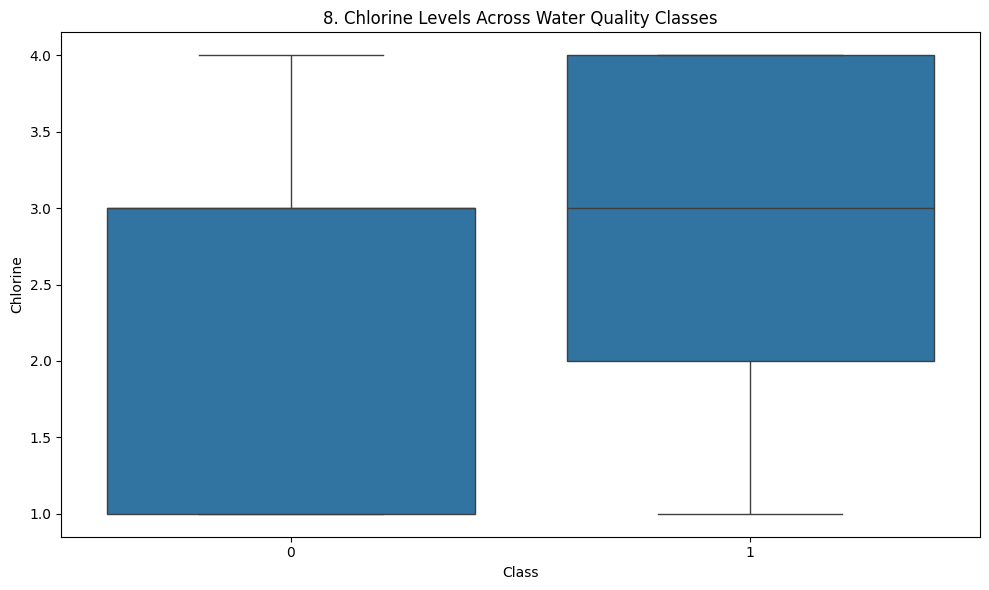

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='Chlorine')
plt.title(f'{plot_no}. Chlorine Levels Across Water Quality Classes')
show_fig()
plot_no += 1

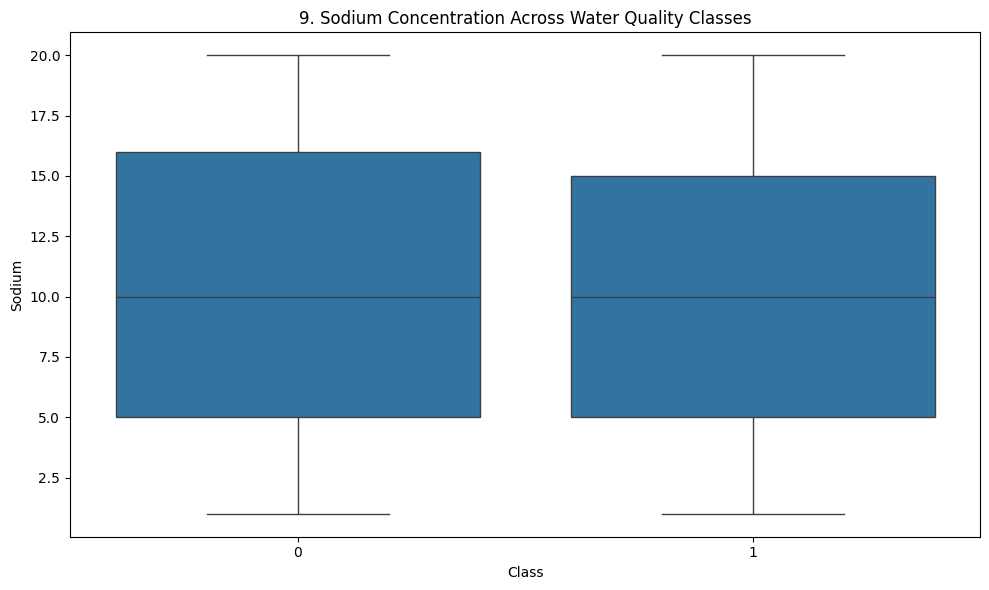

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='Sodium')
plt.title(f'{plot_no}. Sodium Concentration Across Water Quality Classes')
show_fig()
plot_no += 1

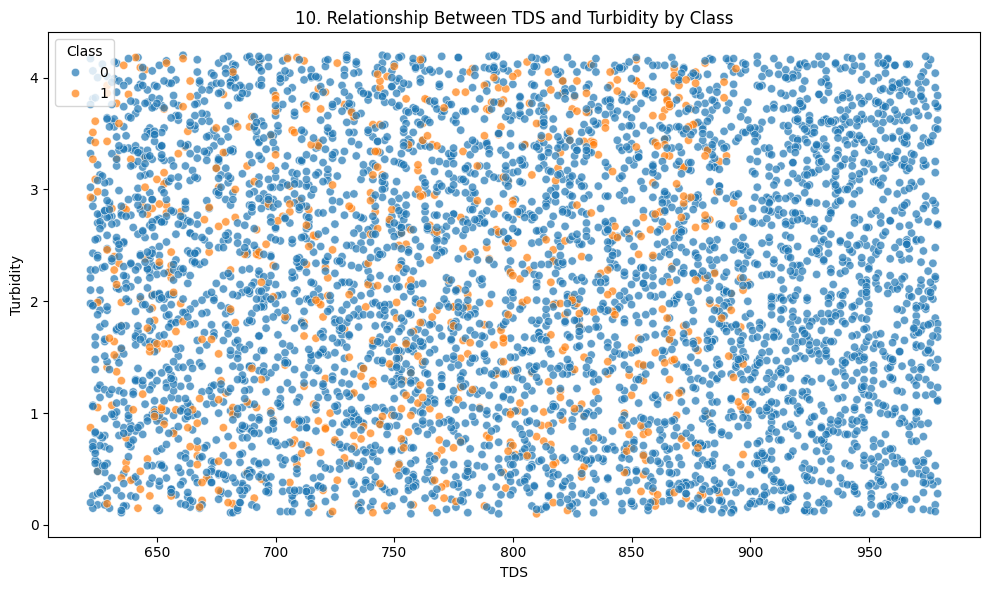

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='TDS', y='Turbidity', hue='Class', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between TDS and Turbidity by Class')
show_fig()
plot_no += 1

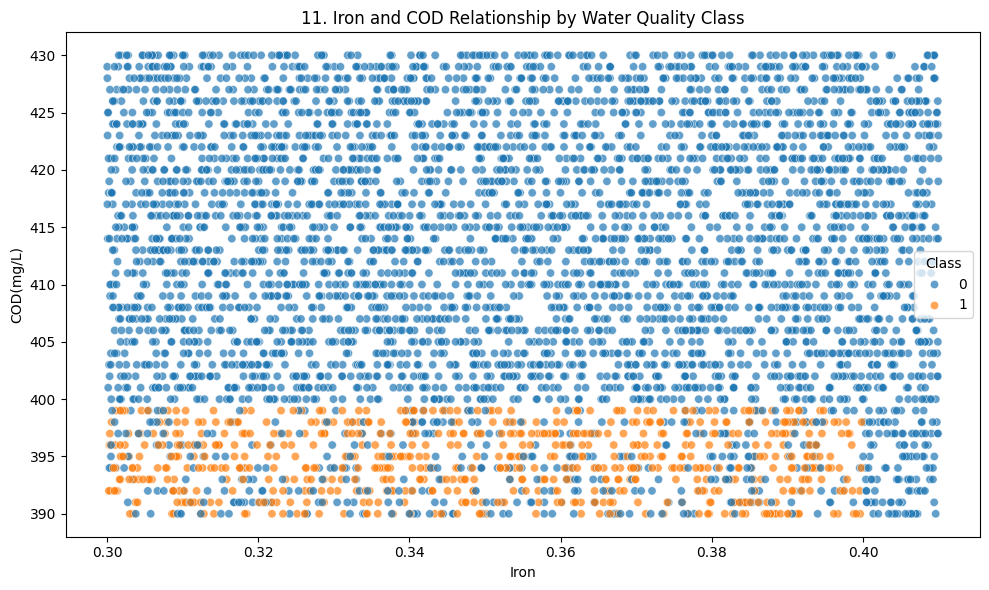

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Iron', y='COD(mg/L)', hue='Class', alpha=0.7)
plt.title(f'{plot_no}. Iron and COD Relationship by Water Quality Class')
show_fig()
plot_no += 1

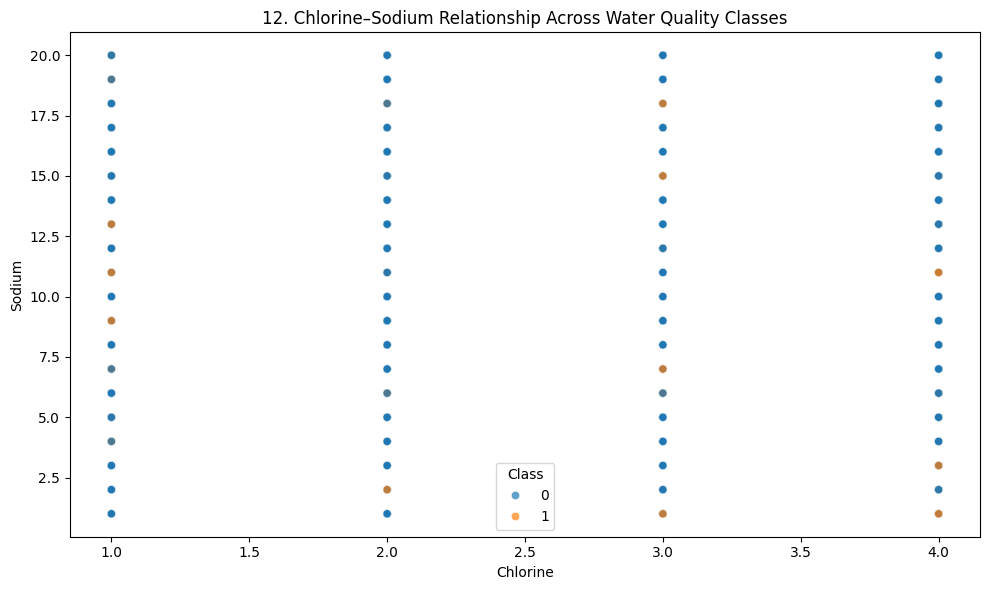

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Chlorine', y='Sodium', hue='Class', alpha=0.7)
plt.title(f'{plot_no}. Chlorine–Sodium Relationship Across Water Quality Classes')
show_fig()
plot_no += 1

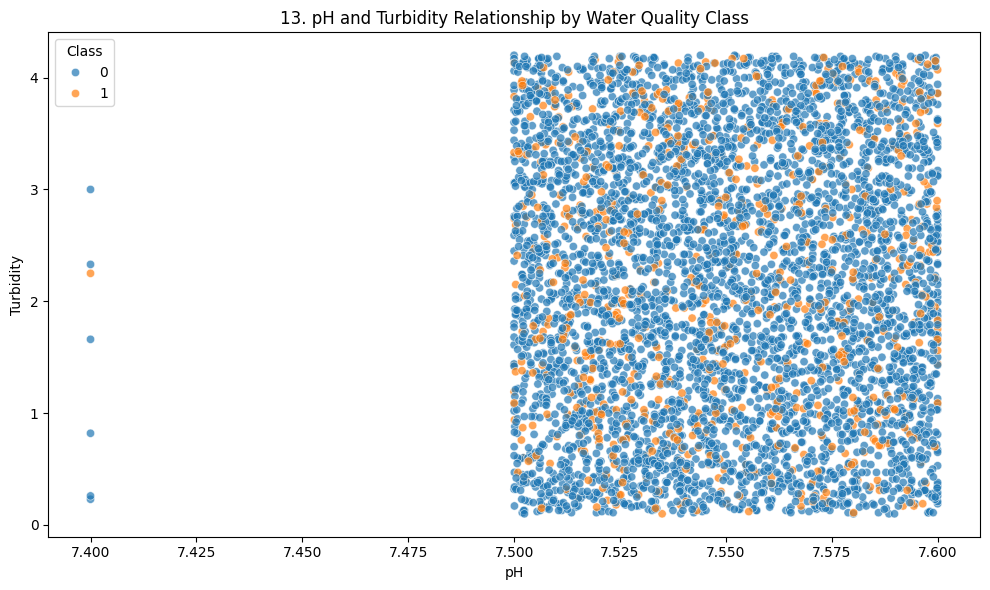

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='pH', y='Turbidity', hue='Class', alpha=0.7)
plt.title(f'{plot_no}. pH and Turbidity Relationship by Water Quality Class')
show_fig()
plot_no += 1

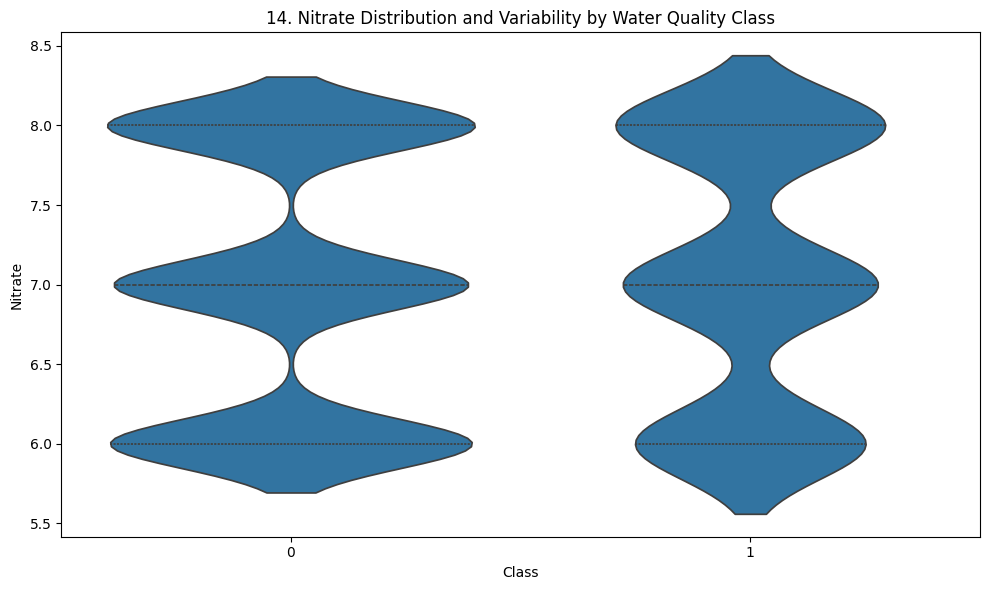

In [26]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Class', y='Nitrate', inner='quartile')
plt.title(f'{plot_no}. Nitrate Distribution and Variability by Water Quality Class')
show_fig()
plot_no += 1

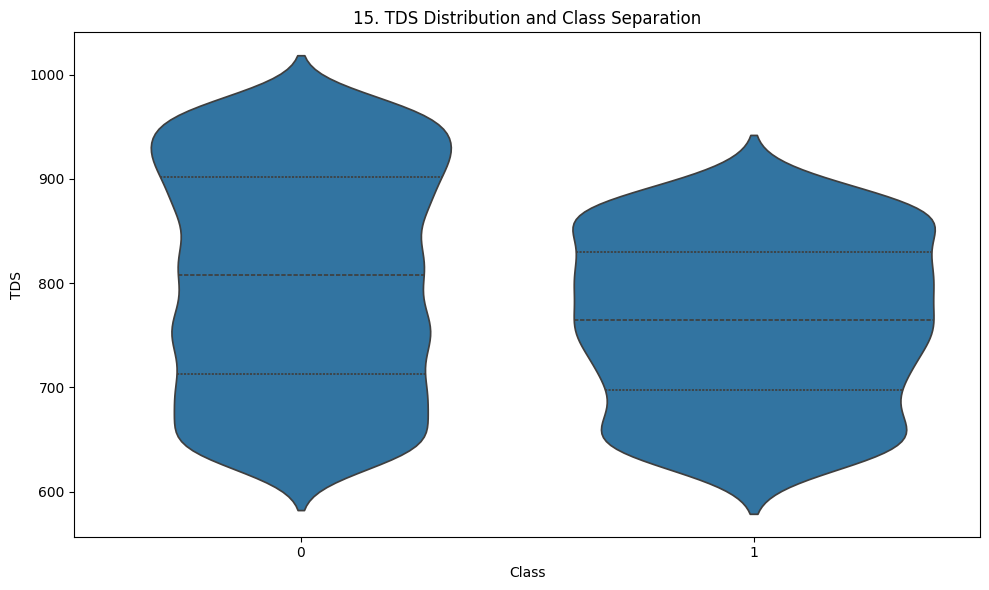

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Class', y='TDS', inner='quartile')
plt.title(f'{plot_no}. TDS Distribution and Class Separation')
show_fig()
plot_no += 1

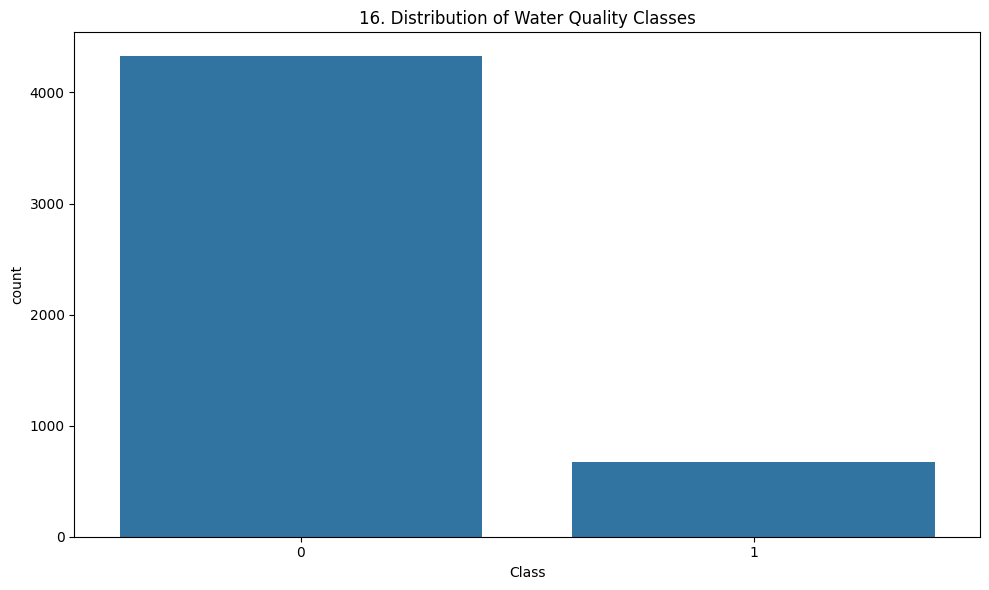

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Class')
plt.title(f'{plot_no}. Distribution of Water Quality Classes')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

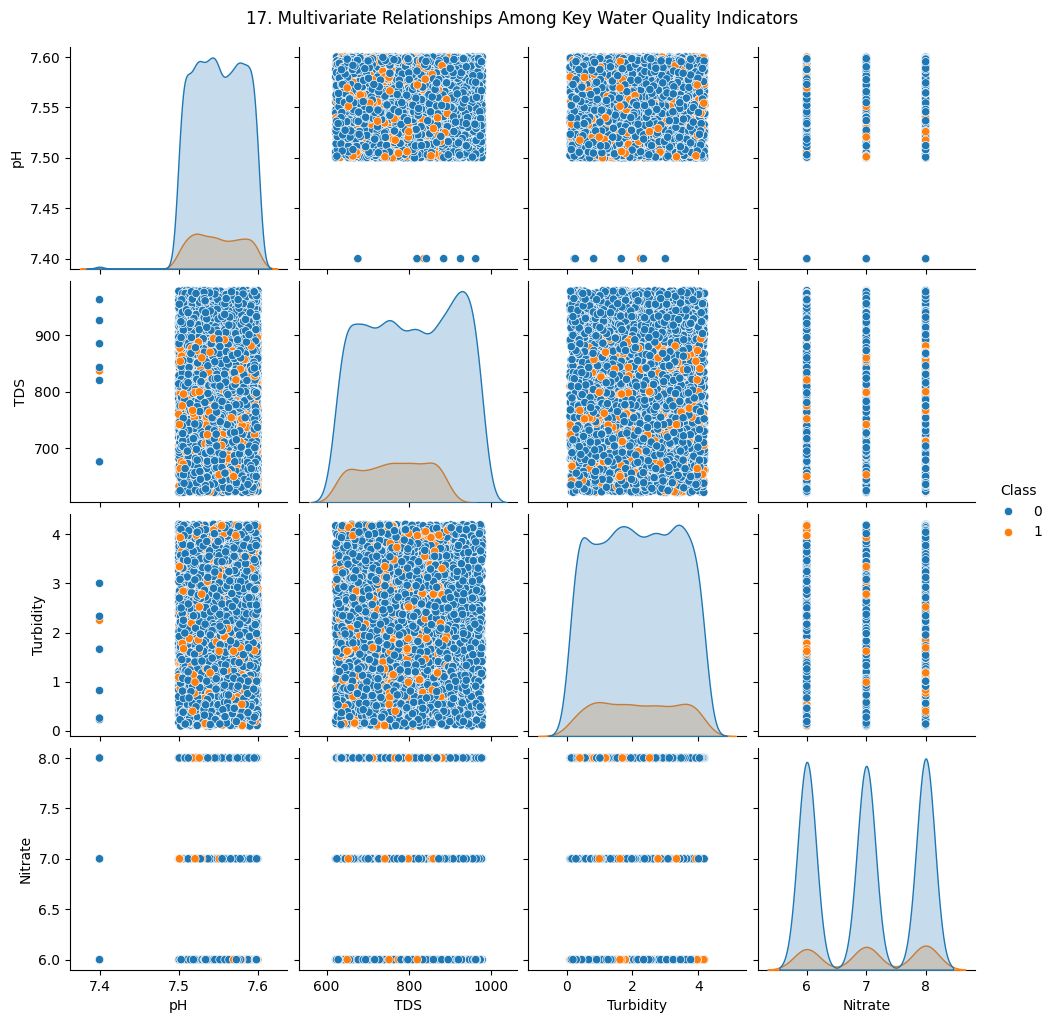

In [29]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df, vars=['pH', 'TDS', 'Turbidity', 'Nitrate'], hue='Class')
plt.suptitle(f'{plot_no}. Multivariate Relationships Among Key Water Quality Indicators', y=1.02)
plt.show()
plot_no += 1

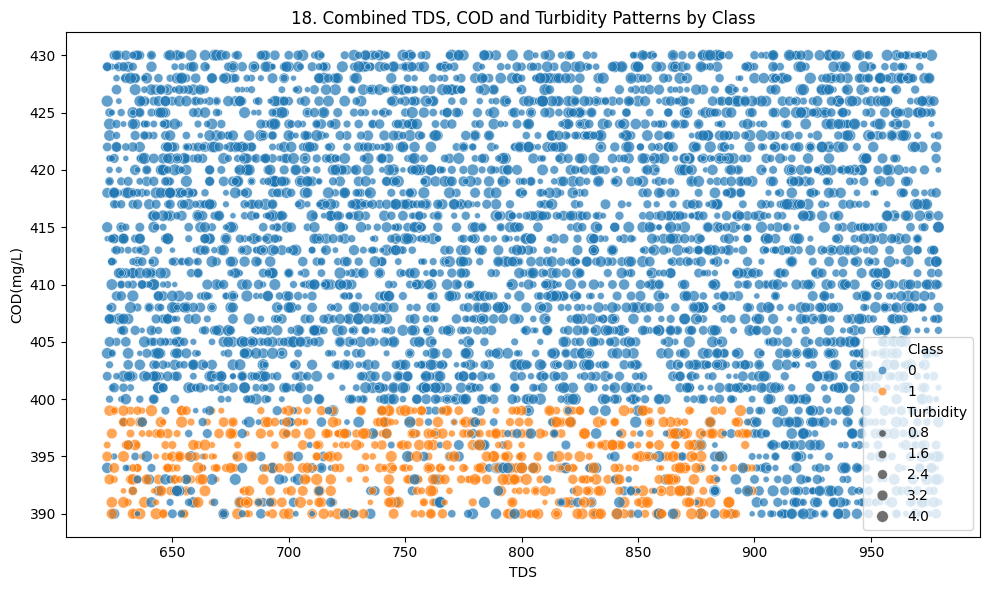

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='TDS', y='COD(mg/L)', size='Turbidity', hue='Class', alpha=0.7)
plt.title(f'{plot_no}. Combined TDS, COD and Turbidity Patterns by Class')
show_fig()
plot_no += 1

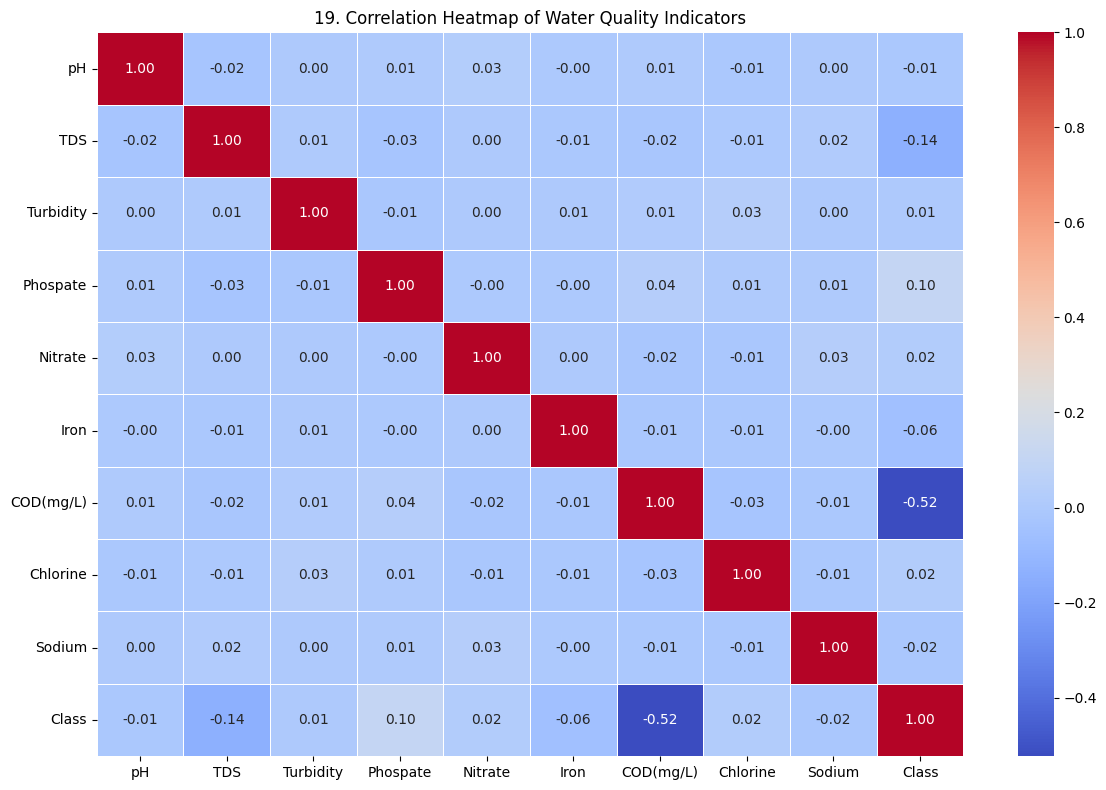

In [31]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Water Quality Indicators')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [32]:
X = df.drop(columns=['Class'])
y = df['Class']

## Split the dataset

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Build the model with scaling

In [34]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=3,
        random_state=42
    ))
])

## Train the model

In [35]:
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'log_loss'
,learning_rate,0.08
,n_estimators,150
,subsample,1.0


## Make predictions

In [36]:
y_pred = model.predict(X_test)

## Calculate model accuracy

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 99.90%


## Plot confusion matrix

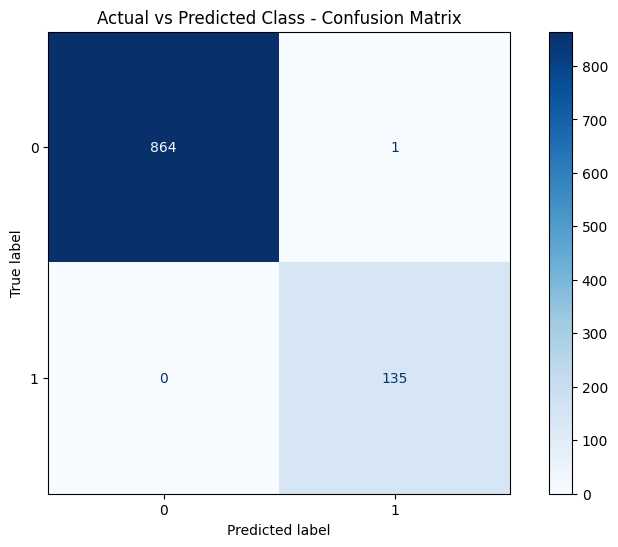

In [38]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=plt.gca(), cmap='Blues')
plt.title('Actual vs Predicted Class - Confusion Matrix')
plt.show()